In this assignment, you must implement an ACO version to solve the **vehicle routing problem**.

*Capacitated Vehicle Routing Problem (CVRP)*: is a vehicle routing problem in which a fleet of identical vehicles of finite capacity and located at a central depot must service a set of customers with known demands. The objective is to determine a set of vehicle trips of minimum total cost (sum of travel distance or time), such that each vehicle starts and ends at the depot, each client is visited exactly once, and the total demand handled by any vehicle does not exceed its capacity.

*Data*: cvrp.txt
- first line: vehicle capacity
- second line (depot): x-coordinate, y-coordinate
- remaining lines (customers): x coordinate, y coordinate, demand

You can consider that a delivery doesn't take any time, i.e., the total cost is calculated based on the distance travelled. Also, the vehicles do not have a time threshold, i.e., each vehicle can travel for as long as you want.

# Set up

In [83]:
# imports
import math
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import itertools
from typing import List, Tuple
import time
import numpy as np

In [84]:
# parsing the input file
def parse_input_file_cvrp(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        vehicle_capacity = int(lines[0].strip())
        depot = tuple(map(float, lines[1].strip().split()))
        customers = []
        for line in lines[2:]:
            parts = line.strip().split()
            x = float(parts[0])
            y = float(parts[1])
            demand = int(parts[2])
            customers.append((x, y, demand))
    return vehicle_capacity, depot, customers

In [85]:
file_path_cvrp = 'cvrp.txt'
vehicle_capacity, depot, customers = parse_input_file_cvrp(file_path_cvrp)
print(f"Vehicle Capacity: {vehicle_capacity}")
print(f"Depot: {depot}")
print(f"Customers: {customers}")

Node = Tuple[float, float]
Customer = Tuple[float, float, float] # x, y, demand
Route = List[int]

Vehicle Capacity: 160
Depot: (30.0, 40.0)
Customers: [(37.0, 52.0, 7), (49.0, 49.0, 30), (52.0, 64.0, 16), (20.0, 26.0, 9), (40.0, 30.0, 21), (21.0, 47.0, 15), (17.0, 63.0, 19), (31.0, 62.0, 23), (52.0, 33.0, 11), (51.0, 21.0, 5), (42.0, 41.0, 19), (31.0, 32.0, 29), (5.0, 25.0, 23), (12.0, 42.0, 21), (36.0, 16.0, 10), (52.0, 41.0, 15), (27.0, 23.0, 3), (17.0, 33.0, 41), (13.0, 13.0, 9), (57.0, 58.0, 28), (62.0, 42.0, 8), (42.0, 57.0, 8), (16.0, 57.0, 16), (8.0, 52.0, 10), (7.0, 38.0, 28), (27.0, 68.0, 7), (30.0, 48.0, 15), (43.0, 67.0, 14), (58.0, 48.0, 6), (58.0, 27.0, 19), (37.0, 69.0, 11), (38.0, 46.0, 12), (46.0, 10.0, 23), (61.0, 33.0, 26), (62.0, 63.0, 17), (63.0, 69.0, 6), (32.0, 22.0, 9), (45.0, 35.0, 15), (59.0, 15.0, 14), (5.0, 6.0, 7), (10.0, 17.0, 27), (21.0, 10.0, 13), (5.0, 64.0, 11), (30.0, 15.0, 16), (39.0, 10.0, 10), (32.0, 39.0, 5), (25.0, 32.0, 25), (25.0, 55.0, 17), (48.0, 28.0, 18), (56.0, 37.0, 10)]


In [86]:
# plotting the depot and customers
def plot_cvrp(depot, customers):
    plt.figure(figsize=(8, 6))
    plt.scatter(depot[0], depot[1], c='red', marker='s', label='Depot')
    for customer in customers:
        plt.scatter(customer[0], customer[1], c='blue', marker='o', label='Customer')
    plt.title('CVRP Depot and Customers')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

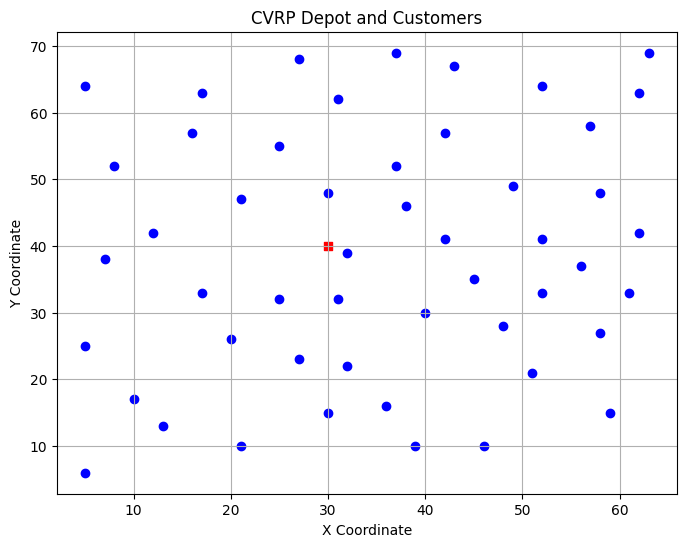

In [87]:
plot_cvrp(depot, customers)

In [88]:
def plot_routes(depot: Node, customers: List[Customer], routes: List[Route]):
    plt.figure(figsize=(8, 6))
    plt.scatter(depot[0], depot[1], c='red', marker='s', label='Depot')
    
    for customer in customers:
        plt.scatter(customer[0], customer[1], c='blue', marker='o', label='Customer')
    
    colors = ['green', 'orange', 'purple', 'cyan', 'magenta']
    for i, route in enumerate(routes):
        route_nodes = [0] + route + [0] # Start and end at depot
        route_coords = [(depot[0], depot[1])] + [(customers[node-1][0], customers[node-1][1]) for node in route] + [(depot[0], depot[1])]
        xs, ys = zip(*route_coords)
        plt.plot(xs, ys, color=colors[i % len(colors)], label=f'Route {i+1}')
    
    plt.title('CVRP Routes')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

## Algorithm
### GRASP (Greedy Randomized Adaptive Search Procedures)
- builds distance matrix of all nodes first
- route cost is calculated by summing over all the distances in a route
- randomized greedy search: find all feasible customers (that are within the capacity of the vehicle in the route), if no more feasible return to depot, calculate the cost of feasible next costumers, parameter alpha defines a threshold within the range of costs, build restricted candidate list, choose of of them at random
- 2-opt local search: trys every combination of swapping 2 nodes to see if the result improves ("untangles" the solution)

In [89]:
class GRASP_CVRP:
    def __init__(self, vehicle_capacity: float, depot: Node, customers: List[Customer]):
        self.capacity = vehicle_capacity
        self.depot = depot
        self.customers = customers
        
        # Node 0 is depot, 1 to N are customers
        self.nodes = [(depot[0], depot[1], 0.0)] + customers
        self.num_nodes = len(self.nodes)
        self.distance_matrix = self._build_distance_matrix()

    def _build_distance_matrix(self) -> List[List[float]]:
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    matrix[i][j] = math.dist(self.nodes[i][:2], self.nodes[j][:2])
        return matrix

    def calculate_route_cost(self, route: Route) -> float:
        cost = 0.0
        # Start from depot
        current_node = 0
        for node in route:
            cost += self.distance_matrix[current_node][node]
            current_node = node
        # Return to depot
        cost += self.distance_matrix[current_node][0]
        return cost

    def _construct_randomized_greedy_solution(self, alpha: float) -> List[Route]:
        unvisited = set(range(1, self.num_nodes))
        routes = []
        
        while unvisited:
            current_route = []
            current_load = 0.0
            current_node = 0 # Start at depot
            
            while unvisited:
                # Find feasible candidates (demand fits remaining capacity)
                feasible_candidates = [
                    c for c in unvisited 
                    if current_load + self.nodes[c][2] <= self.capacity
                ]
                
                if not feasible_candidates:
                    break # Vehicle is full, return to depot (end route)
                
                # Calculate costs for feasible candidates
                costs = {c: self.distance_matrix[current_node][c] for c in feasible_candidates}
                c_min = min(costs.values())
                c_max = max(costs.values())
                
                # Build Restricted Candidate List (RCL)
                threshold = c_min + alpha * (c_max - c_min)
                rcl = [c for c, cost in costs.items() if cost <= threshold]
                
                # Randomly pick from RCL
                next_node = random.choice(rcl)
                
                # Update state
                current_route.append(next_node)
                current_load += self.nodes[next_node][2]
                unvisited.remove(next_node)
                current_node = next_node
                
            routes.append(current_route)
            
        return routes

    def _local_search_2opt(self, route: Route) -> Route:
        """Applies 2-opt intra-route optimization to a single route."""
        best_route = route.copy()
        best_cost = self.calculate_route_cost(best_route)
        improved = True
        
        while improved:
            improved = False
            for i in range(1, len(best_route) - 2):
                for j in range(i + 1, len(best_route)):
                    if j - i == 1: continue # Skip adjacent edges
                    
                    # 2-opt swap
                    new_route = best_route[:]
                    new_route[i:j] = best_route[j-1:i-1:-1]
                    
                    new_cost = self.calculate_route_cost(new_route)
                    if new_cost < best_cost:
                        best_route = new_route
                        best_cost = new_cost
                        improved = True
        return best_route

    def solve(self, iterations: int = 50, alpha: float = 0.2) -> Tuple[List[Route], float]:
        best_all_routes = None
        best_total_cost = float('inf')

        for _ in range(iterations):
            # 1. Construction Phase
            routes = self._construct_randomized_greedy_solution(alpha)
            
            # 2. Local Search Phase (optimize each route individually)
            optimized_routes = []
            total_cost = 0.0
            
            for route in routes:
                opt_route = self._local_search_2opt(route)
                optimized_routes.append(opt_route)
                total_cost += self.calculate_route_cost(opt_route)
                
            # 3. Update Best Solution
            if total_cost < best_total_cost:
                best_total_cost = total_cost
                best_all_routes = optimized_routes
                
        return best_all_routes, best_total_cost

Best Cost: 748.5314144293485
Routes: [[5, 10, 45, 15, 44, 17, 19, 4, 18, 12, 1], [46, 47, 32, 8, 26, 48, 6, 24, 23, 7, 43], [11, 38, 9, 50, 16, 20, 21, 34, 49, 37], [27, 14, 25, 13, 41, 40, 42, 33], [22, 31, 28, 3, 36, 35, 29, 2, 30, 39]]


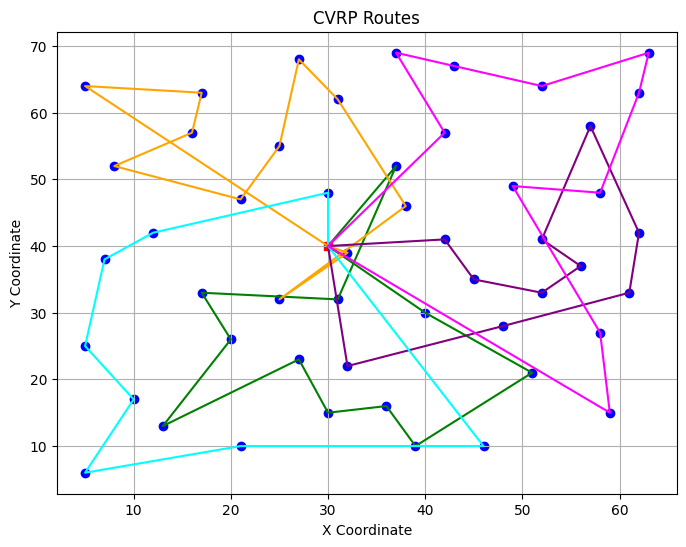

In [90]:
# Run GRASP
solver = GRASP_CVRP(vehicle_capacity, depot, customers)
best_routes, best_cost = solver.solve(iterations=100, alpha=0.3)
print(f"Best Cost: {best_cost}")
print(f"Routes: {best_routes}")
plot_routes(depot, customers, best_routes)

### AOC (Ant Colony Optimization)
- calculates the distance matrix once -> derives the heuristic matrix from it (1/distance)
- solution cost = summing over all distances in each route for the solution
- next node selection like described in the slides (cognitive term + social term)
- pheromone update: slight evaporations over time, only the iterations best ant desposits pheromones
- added local search on top: 2-opt. 

In [ ]:
# Type aliases
Node = Tuple[float, float]
Customer = Tuple[float, float, float] # x, y, demand
Route = List[int]
Solution = List[Route]

class ACO_CVRP:
    def __init__(self, vehicle_capacity: float, depot: Node, customers: List[Customer],
                 num_ants: int = 20, iterations: int = 100,
                 alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1, Q: float = 1.0):
        
        self.capacity = vehicle_capacity
        self.nodes = [(depot[0], depot[1], 0.0)] + customers
        self.num_nodes = len(self.nodes)
        
        # ACO Parameters
        self.num_ants = num_ants
        self.iterations = iterations
        self.alpha = alpha   # Pheromone importance
        self.beta = beta     # Heuristic importance
        self.rho = rho       # Evaporation rate
        self.Q = Q           # Deposit constant
        
        # Initialize Matrices
        self.distance_matrix = self._build_distance_matrix()
        self.heuristic_matrix = self._build_heuristic_matrix()
        
        # Initial pheromone value (tau_0)
        self.tau_0 = 0.1 
        self.pheromone_matrix = [[self.tau_0] * self.num_nodes for _ in range(self.num_nodes)]

    def _build_distance_matrix(self) -> List[List[float]]:
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    matrix[i][j] = math.dist(self.nodes[i][:2], self.nodes[j][:2])
        return matrix

    def _build_heuristic_matrix(self) -> List[List[float]]:
        """Calculates eta_ij = 1 / d_ij"""
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j and self.distance_matrix[i][j] > 0:
                    matrix[i][j] = 1.0 / self.distance_matrix[i][j]
        return matrix

    def calculate_solution_cost(self, solution: Solution) -> float:
        """Sums the cost of all routes in a solution."""
        total_cost = 0.0
        for route in solution:
            current_node = 0
            for node in route:
                total_cost += self.distance_matrix[current_node][node]
                current_node = node
            total_cost += self.distance_matrix[current_node][0]
        return total_cost

    def _select_next_node(self, current_node: int, unvisited: set, current_load: float) -> int:
        """Calculates transition probabilities and selects the next node."""
        feasible_neighbors = [
            n for n in unvisited 
            if current_load + self.nodes[n][2] <= self.capacity
        ]
        
        # If no customer fits, the ant MUST return to the depot (node 0)
        if not feasible_neighbors:
            return 0
            
        probabilities = []
        denominator = 0.0
        
        # Calculate scores for feasible neighbors
        for j in feasible_neighbors:
            tau = self.pheromone_matrix[current_node][j] ** self.alpha
            eta = self.heuristic_matrix[current_node][j] ** self.beta
            score = tau * eta
            probabilities.append((j, score))
            denominator += score
            
        # Roulette wheel selection
        rand_val = random.random()
        cumulative_prob = 0.0
        
        for j, score in probabilities:
            prob = score / denominator
            cumulative_prob += prob
            if rand_val <= cumulative_prob:
                return j
                
        return feasible_neighbors[-1] # Fallback for floating point inaccuracies

    def _build_ant_solution(self) -> Solution:
        """Simulates one ant building a full CVRP solution."""
        unvisited = set(range(1, self.num_nodes))
        solution = []
        
        while unvisited:
            route = []
            current_load = 0.0
            current_node = 0 # Start at depot
            
            while unvisited:
                next_node = self._select_next_node(current_node, unvisited, current_load)
                
                if next_node == 0:
                    break # Capacity reached, end this route
                    
                route.append(next_node)
                current_load += self.nodes[next_node][2]
                unvisited.remove(next_node)
                current_node = next_node
                
            if route:
                solution.append(route)
                
        return solution

    def _update_pheromones(self, all_solutions: List[Tuple[Solution, float]], best_solution: Solution, best_cost: float):
        """Applies evaporation and Elitist deposit."""
        # 1. Evaporation (apply to all edges)
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                self.pheromone_matrix[i][j] *= (1.0 - self.rho)
                
        # 2. Deposit (Elitist strategy: only the iteration's best ant deposits)
        deposit_amount = self.Q / best_cost
        # print(f"Depositing pheromone for best solution with cost {best_cost:.2f}, deposit amount: {deposit_amount:.4f}")
        
        for route in best_solution:
            current_node = 0
            for node in route:
                self.pheromone_matrix[current_node][node] += deposit_amount
                # If symmetric TSP/CVRP, update the reverse direction too:
                self.pheromone_matrix[node][current_node] += deposit_amount 
                current_node = node
            # Don't forget the return to depot
            self.pheromone_matrix[current_node][0] += deposit_amount
            self.pheromone_matrix[0][current_node] += deposit_amount

    def solve(self) -> Tuple[Solution, float]:
        global_best_solution = None
        global_best_cost = float('inf')
        
        for iteration in range(self.iterations):
            ant_solutions = []
            iteration_best_solution = None
            iteration_best_cost = float('inf')
            
            # Step 1: All ants build solutions
            for _ in range(self.num_ants):
                solution = self._build_ant_solution()
                cost = self.calculate_solution_cost(solution)
                ant_solutions.append((solution, cost))
                
                # Check for iteration best
                if cost < iteration_best_cost:
                    iteration_best_cost = cost
                    iteration_best_solution = solution
                    
            # Check for global best
            if iteration_best_cost < global_best_cost:
                global_best_cost = iteration_best_cost
                global_best_solution = iteration_best_solution
                
            # Step 2: Update Pheromones
            self._update_pheromones(ant_solutions, iteration_best_solution, iteration_best_cost)
            
            # Optional: Print progress
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Best Cost = {global_best_cost:.2f}")
                
        return global_best_solution, global_best_cost
    
    def calculate_route_cost(self, route: Route) -> float:
        """Calculates the cost of a single route (depot -> nodes -> depot)."""
        if not route:
            return 0.0
            
        cost = 0.0
        current_node = 0
        for node in route:
            cost += self.distance_matrix[current_node][node]
            current_node = node
        cost += self.distance_matrix[current_node][0]
        return cost
    
    def _local_search_2opt(self, route: Route) -> Route:
        """Applies 2-opt intra-route optimization to a single route."""
        best_route = route.copy()
        best_cost = self.calculate_route_cost(best_route)
        improved = True
        
        while improved:
            improved = False
            for i in range(1, len(best_route) - 2):
                for j in range(i + 1, len(best_route)):
                    if j - i == 1: continue # Skip adjacent edges
                    
                    # 2-opt swap
                    new_route = best_route[:]
                    new_route[i:j] = best_route[j-1:i-1:-1]
                    
                    new_cost = self.calculate_route_cost(new_route) 
                    
                    if new_cost < best_cost:
                        best_route = new_route
                        best_cost = new_cost
                        improved = True
        return best_route
    
    def solve_with2opt(self) -> Tuple[Solution, float]:
        global_best_solution = None
        global_best_cost = float('inf')
        
        for iteration in range(self.iterations):
            ant_solutions = []
            iteration_best_solution = None
            iteration_best_cost = float('inf')
            
            # Step 1: All ants build solutions
            for _ in range(self.num_ants):
                # 1a. Ant builds a raw, potentially tangled solution
                raw_solution = self._build_ant_solution()
                
                # 1b. HYBRID INTEGRATION: Apply Local Search to educate the ant
                optimized_solution = []
                for route in raw_solution:
                    # Optimize each vehicle's route individually
                    optimized_route = self._local_search_2opt(route)
                    optimized_solution.append(optimized_route)
                
                # 1c. Calculate the cost of the OPTIMIZED solution
                cost = self.calculate_solution_cost(optimized_solution)
                
                # Store the optimized version, not the raw one
                ant_solutions.append((optimized_solution, cost))
                
                # Check for iteration best
                if cost < iteration_best_cost:
                    iteration_best_cost = cost
                    iteration_best_solution = optimized_solution
                    
            # Check for global best
            if iteration_best_cost < global_best_cost:
                global_best_cost = iteration_best_cost
                global_best_solution = iteration_best_solution
                
            # Step 2: Update Pheromones
            self._update_pheromones(ant_solutions, iteration_best_solution, iteration_best_cost)
            
            # Optional: Print progress
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Best Cost = {global_best_cost:.2f}")
                
        return global_best_solution, global_best_cost

Iteration 0: Best Cost = 934.19
Iteration 10: Best Cost = 710.13
Iteration 20: Best Cost = 637.34
Iteration 30: Best Cost = 631.08
Iteration 40: Best Cost = 622.22
Iteration 50: Best Cost = 622.22
Iteration 60: Best Cost = 622.22
Iteration 70: Best Cost = 622.22
Iteration 80: Best Cost = 618.21
Iteration 90: Best Cost = 607.81
Best Cost from ACO: 605.0684805707117
Best Solution (Routes): [[46, 12, 47, 4, 18, 14, 25], [27, 48, 6, 24, 43, 7, 23, 26, 8, 31, 28], [17, 37, 15, 45, 33, 10, 39, 30, 34, 50, 9, 16], [11, 32, 2, 29, 21, 20, 35, 36, 3, 22, 1], [49, 38, 5, 44, 42, 19, 41, 13, 40]]


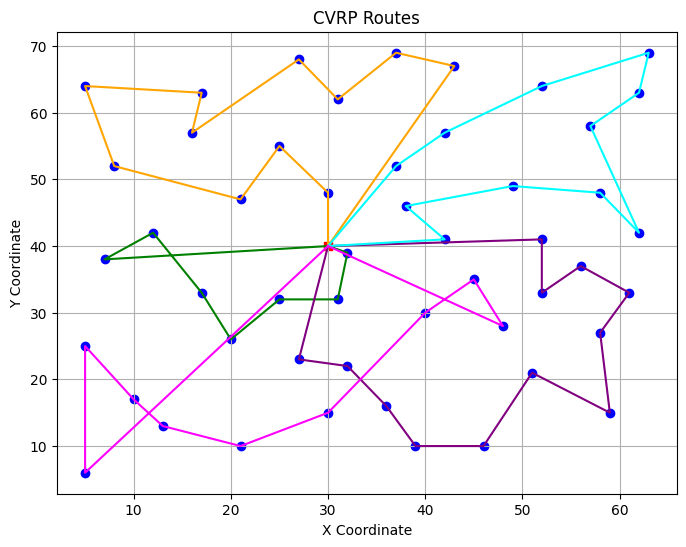

In [92]:
aoc_solver = ACO_CVRP(vehicle_capacity, depot, customers, num_ants=30, iterations=100, alpha=1.0, beta=2.0, rho=0.1, Q=500.0)
best_solution, best_cost = aoc_solver.solve()
print(f"Best Cost from ACO: {best_cost}")
print(f"Best Solution (Routes): {best_solution}")
plot_routes(depot, customers, best_solution)

Iteration 0: Best Cost = 599.92
Iteration 10: Best Cost = 592.23
Iteration 20: Best Cost = 581.04
Iteration 30: Best Cost = 581.04
Iteration 40: Best Cost = 578.90
Iteration 50: Best Cost = 576.69
Iteration 60: Best Cost = 576.69
Iteration 70: Best Cost = 576.69
Iteration 80: Best Cost = 576.69
Iteration 90: Best Cost = 576.69
Best Cost from ACO: 576.6885643533623
Best Solution (Routes): [[46, 12, 47, 4, 18, 14, 25], [1, 22, 3, 36, 35, 20, 29, 16, 50, 9, 38, 11], [32, 2, 21, 34, 30, 39, 10, 49, 5, 17], [27, 48, 6, 24, 43, 23, 7, 26, 8, 31, 28], [37, 15, 33, 45, 44, 42, 19, 40, 41, 13]]


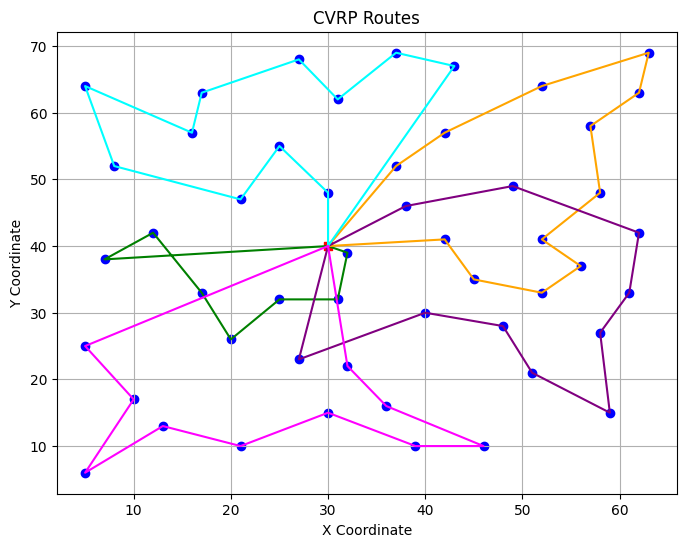

In [93]:
best_solution, best_cost = aoc_solver.solve_with2opt()
print(f"Best Cost from ACO: {best_cost}")
print(f"Best Solution (Routes): {best_solution}")
plot_routes(depot, customers, best_solution)

The quality of the solution increases over the different implementations. GRASP baseline < AOC < AOC + local search. You can clearly see the effect of the added local search because solutions get untangled. 

### Parameter Tuning 
Grid Search

In [ ]:
def tune_aco_hyperparameters(vehicle_capacity, depot, customers):
    # 1. Define the parameter grid
    alphas = [1.0, 2.0]        # Pheromone importance
    betas = [2.0, 3.5, 5.0]    # Heuristic importance (usually > alpha)
    rhos = [0.1, 0.3]          # Evaporation rate
    
    # Generate all combinations of the parameters
    param_combinations = list(itertools.product(alphas, betas, rhos))
    print(f"Starting Grid Search with {len(param_combinations)} combinations...\n")
    
    best_overall_cost = float('inf')
    best_params = None
    results = []
    
    # 2. Loop through every combination
    for idx, (alpha, beta, rho) in enumerate(param_combinations):
        for i in range(5): 
            print(f"[{idx+1}/{len(param_combinations)}] Testing: alpha={alpha}, beta={beta}, rho={rho}")
            
            start_time = time.time()
            
            # Instantiate the solver with the current hyperparameters
            # We use fewer ants and iterations just to gauge the parameters' effectiveness
            solver = ACO_CVRP(
                vehicle_capacity=vehicle_capacity, 
                depot=depot, 
                customers=customers,
                num_ants=50,       
                iterations=100,     
                alpha=alpha, 
                beta=beta, 
                rho=rho,
                Q=500.0
            )
            
            # Run the solver using the Hybrid approach (with 2-opt)
            best_solution, best_cost = solver.solve_with2opt()
            
            elapsed_time = time.time() - start_time
            print(f"    -> Result: Cost = {best_cost:.2f} (Took {elapsed_time:.2f} seconds)\n")
            
            # Store results for analysis
            results.append({
                'alpha': alpha, 'beta': beta, 'rho': rho, 
                'cost': best_cost, 'time': elapsed_time
            })
            
            # Track the global best
            if best_cost < best_overall_cost:
                best_overall_cost = best_cost
                best_overall_solution = best_solution
                best_params = {'alpha': alpha, 'beta': beta, 'rho': rho}
            
    # 3. Output the final verdict
    print("-" * 30)
    print("GRID SEARCH COMPLETE")
    print("-" * 30)
    print(f"Best Parameters: {best_params}")
    print(f"Best Cost Found: {best_overall_cost:.2f}")
    
    return best_params, results, best_overall_solution

Starting Grid Search with 12 combinations...

[1/12] Testing: alpha=1.0, beta=2.0, rho=0.1
Iteration 0: Best Cost = 818.76
Iteration 10: Best Cost = 628.03
Iteration 20: Best Cost = 628.03
Iteration 30: Best Cost = 607.62
Iteration 40: Best Cost = 603.87
Iteration 50: Best Cost = 595.20
Iteration 60: Best Cost = 587.87
Iteration 70: Best Cost = 587.87
Iteration 80: Best Cost = 576.96
Iteration 90: Best Cost = 576.96
    -> Result: Cost = 576.96 (Took 1.64 seconds)

[1/12] Testing: alpha=1.0, beta=2.0, rho=0.1
Iteration 0: Best Cost = 824.86
Iteration 10: Best Cost = 636.20
Iteration 20: Best Cost = 631.73
Iteration 30: Best Cost = 604.35
Iteration 40: Best Cost = 588.27
Iteration 50: Best Cost = 588.27
Iteration 60: Best Cost = 588.27
Iteration 70: Best Cost = 588.27
Iteration 80: Best Cost = 575.48
Iteration 90: Best Cost = 575.48
    -> Result: Cost = 571.61 (Took 1.67 seconds)

[1/12] Testing: alpha=1.0, beta=2.0, rho=0.1
Iteration 0: Best Cost = 815.89
Iteration 10: Best Cost = 589

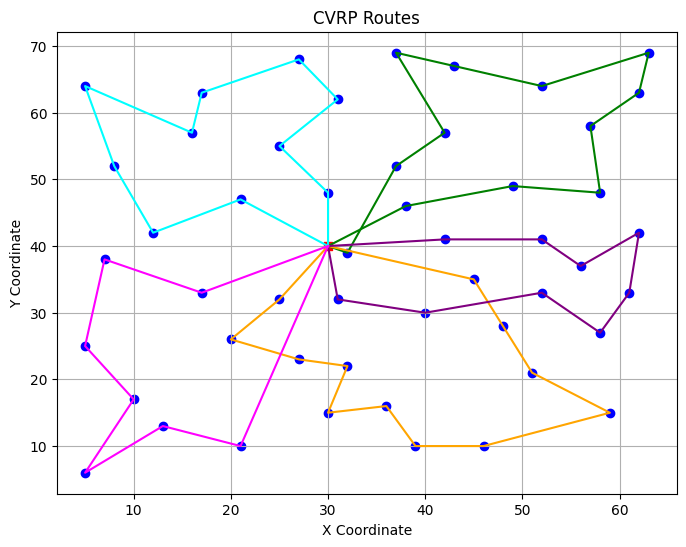

In [95]:
best_parameters, _, best_solution = tune_aco_hyperparameters(vehicle_capacity, depot, customers)
plot_routes(depot, customers, best_solution)

---

*Vehicle Routing Problem with Time Windows (VRPTW)*: is a vehicle routing problem in which a fleet of identical vehicles of finite capacity and located at a central depot must service a set of customers with known demands and specific time windows. The objective is to determine a set of vehicle trips of minimum total cost (sum of travel distance or time), such that each vehicle starts and ends at the depot, each client is visited exactly once and within his/her time window, and the total demand handled by any vehicle does not exceed its capacity.

Data: vrptw.txt
- first line: number of vehicles, vehicle capacity
- second line (depot): x-coordinate, y-coordinate
- remaining lines (customers): x coordinate, y coordinate, demand, time window opening, time window closing, service time

You can consider the vehicles to have no time limit, i.e., each vehicle can travel for as long as you want. On the other hand, the delivery takes as much time as indicated in the service time for each customer.

## Set up

In [96]:
# parsing the input file
def parse_input_file_vrptw(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        vehicle_parts = lines[0].strip().split()
        vehicle_number = int(vehicle_parts[0])
        vehicle_capacity = float(vehicle_parts[1])
        depot = tuple(map(float, lines[1].strip().split()))
        customers = []
        for line in lines[2:]:
            parts = line.strip().split()
            x = float(parts[0])
            y = float(parts[1])
            demand = float(parts[2])
            start_time = float(parts[3])
            end_time = float(parts[4])
            service_time = float(parts[5])
            customers.append((x, y, demand, start_time, end_time, service_time))
    return vehicle_number, vehicle_capacity, depot, customers

In [97]:
file_path_vrptw = 'vrptw.txt'
vehicle_number, vehicle_capacity, depot, customers = parse_input_file_vrptw(file_path_vrptw)
print(f"Vehicle Number: {vehicle_number}")
print(f"Vehicle Capacity: {vehicle_capacity}")
print(f"Depot: {depot}")
print(f"Customers: {customers}")

Node = Tuple[float, float]
Customer = Tuple[float, float, float, float, float, float] # x, y, demand, start_time, end_time, service_time
Route = List[int]
Solution = List[Route]

Vehicle Number: 25
Vehicle Capacity: 200.0
Depot: (35.0, 35.0)
Customers: [(41.0, 49.0, 10.0, 161.0, 171.0, 10.0), (35.0, 17.0, 7.0, 50.0, 60.0, 10.0), (55.0, 45.0, 13.0, 116.0, 126.0, 10.0), (55.0, 20.0, 19.0, 149.0, 159.0, 10.0), (15.0, 30.0, 26.0, 34.0, 44.0, 10.0), (25.0, 30.0, 3.0, 99.0, 109.0, 10.0), (20.0, 50.0, 5.0, 81.0, 91.0, 10.0), (10.0, 43.0, 9.0, 95.0, 105.0, 10.0), (55.0, 60.0, 16.0, 97.0, 107.0, 10.0), (30.0, 60.0, 16.0, 124.0, 134.0, 10.0), (20.0, 65.0, 12.0, 67.0, 77.0, 10.0), (50.0, 35.0, 19.0, 63.0, 73.0, 10.0), (30.0, 25.0, 23.0, 159.0, 169.0, 10.0), (15.0, 10.0, 20.0, 32.0, 42.0, 10.0), (30.0, 5.0, 8.0, 61.0, 71.0, 10.0), (10.0, 20.0, 19.0, 75.0, 85.0, 10.0), (5.0, 30.0, 2.0, 157.0, 167.0, 10.0), (20.0, 40.0, 12.0, 87.0, 97.0, 10.0), (15.0, 60.0, 17.0, 76.0, 86.0, 10.0), (45.0, 65.0, 9.0, 126.0, 136.0, 10.0), (45.0, 20.0, 11.0, 62.0, 72.0, 10.0), (45.0, 10.0, 18.0, 97.0, 107.0, 10.0), (55.0, 5.0, 29.0, 68.0, 78.0, 10.0), (65.0, 35.0, 3.0, 153.0, 163.0, 10.0), (65.

In [98]:
def plot_vrptw(depot, customers):
    # Extract coordinates
    depot_x, depot_y = depot[0], depot[1]
    
    # customers list structure: (x, y, demand, open_time, close_time, service_time)
    cust_x = [c[0] for c in customers]
    cust_y = [c[1] for c in customers]
    
    # Use the closing time (or opening time) for the color gradient
    closing_times = [c[4] for c in customers] 
    
    plt.figure(figsize=(10, 8))
    
    # Plot the depot as a distinct, large marker
    plt.scatter(depot_x, depot_y, c='red', marker='s', s=150, label='Depot', zorder=5)
    
    # Plot customers with a colormap based on their closing time
    # 'viridis' goes from purple (early) to yellow (late)
    scatter = plt.scatter(cust_x, cust_y, c=closing_times, cmap='viridis', 
                          s=60, edgecolors='black', zorder=4)
    
    # Add a colorbar to explain the gradient
    cbar = plt.colorbar(scatter)
    cbar.set_label('Time Window Closing Time')
    
    plt.title('VRPTW Customers Color-Coded by Time Window')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

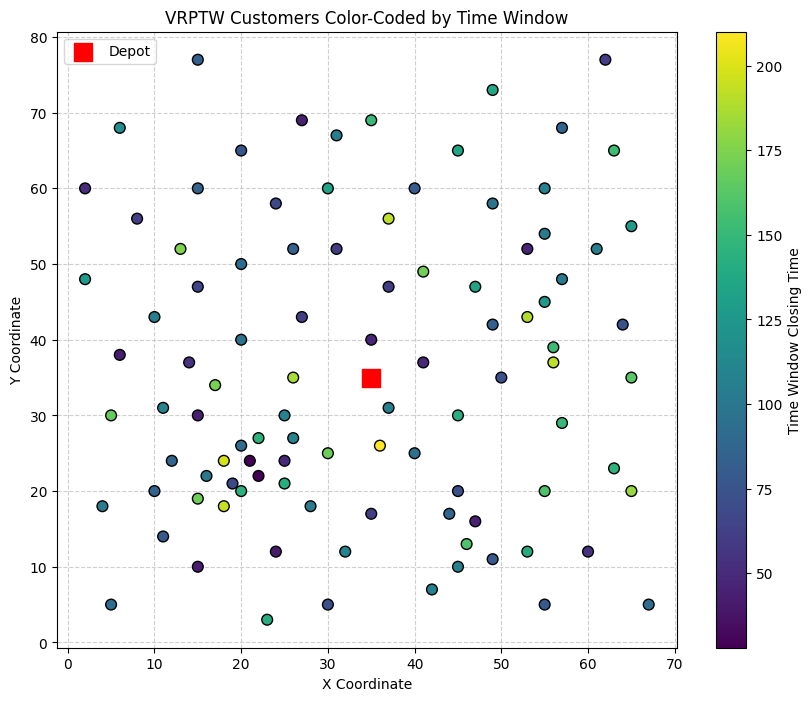

In [99]:
plot_vrptw(depot, customers)

In [100]:
def plot_vrptw_routes(depot, customers, routes):
    """
    Plots the depot, color-coded customers based on close_time, and the vehicle routes.
    
    Args:
        depot: Tuple of (x, y)
        customers: List of tuples (x, y, demand, open_time, close_time, service_time)
        routes: List of lists, where each inner list is a sequence of customer indices (1-indexed)
    """
    # Extract coordinates and times based on the vrptw.txt format
    depot_x, depot_y = depot[0], depot[1]
    
    cust_x = [c[0] for c in customers]
    cust_y = [c[1] for c in customers]
    close_times = [c[4] for c in customers] # Index 4 is the close_time
    
    plt.figure(figsize=(12, 8))
    
    # 1. Plot the Depot
    plt.scatter(depot_x, depot_y, c='red', marker='s', s=150, label='Depot', zorder=5)
    
    # 2. Plot Customers with Time Window Colormap
    scatter = plt.scatter(cust_x, cust_y, c=close_times, cmap='viridis', 
                          s=70, edgecolors='black', zorder=4)
    
    # Add colorbar for time windows
    cbar = plt.colorbar(scatter)
    cbar.set_label('Time Window Closing Time')
    
    # 3. Plot the Routes
    # Generate distinct colors for each route
    route_colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(routes))))
    
    for route_idx, route in enumerate(routes):
        if not route:
            continue
            
        # Build coordinate lists starting and ending at the depot
        route_x = [depot_x]
        route_y = [depot_y]
        
        for node_idx in route:
            # Note: route nodes are 1-indexed (0 is depot), so customer index is node_idx - 1
            cust = customers[node_idx - 1]
            route_x.append(cust[0])
            route_y.append(cust[1])
            
        # Add depot at the end
        route_x.append(depot_x)
        route_y.append(depot_y)
        
        # Draw the line
        plt.plot(route_x, route_y, color=route_colors[route_idx], linewidth=2, 
                 alpha=0.7, zorder=3, label=f'Route {route_idx + 1}')
        
    plt.title('VRPTW Routes with Time Window Color-Coding')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    
    # Move legend outside the plot to prevent clutter
    plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## GRASP
Now including start, end and service time.
Checking feasibility is now not only checking if remaining capacity is enough, but also Vehicle arrives before closing time. Potential wait times if vehicle arrives before open time also has to be calculated. 
New greedy approach:
- now we pick greedily from distance + wait time (instead of just distance)
- if we run out of vehicles and there is still unvisited customers, the solution is invalid

Local Search changed to 2-opt*: Regular 2-opt would break time constraint almost always. Instead of optimizing within one route, 2-opt* takes two routes and swapps subroutes. The timely order stays in tact both in the subroutes and the complete routes.


In [101]:
class GRASP_VRPTW:
    def __init__(self, num_vehicles: int, vehicle_capacity: float, depot: Node, customers: List[Customer]):
        self.num_vehicles = num_vehicles
        self.capacity = vehicle_capacity
        self.depot = depot
        self.customers = customers
        
        # Node 0 is depot (demand 0, time window 0 to infinity, service time 0)
        self.nodes = [(depot[0], depot[1], 0.0, 0.0, float('inf'), 0.0)] + customers
        self.num_nodes = len(self.nodes)
        self.distance_matrix = self._build_distance_matrix()

    def _build_distance_matrix(self) -> List[List[float]]:
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    matrix[i][j] = math.dist(self.nodes[i][:2], self.nodes[j][:2])
        return matrix

    def _check_feasibility_and_time(self, current_node: int, next_node: int, current_time: float, current_load: float) -> Tuple[bool, float]:
        """Checks capacity and time windows, returning (is_feasible, departure_time)."""
        demand = self.nodes[next_node][2]
        open_time = self.nodes[next_node][3]
        close_time = self.nodes[next_node][4]
        service_time = self.nodes[next_node][5]
        
        # 1. Capacity Check
        if current_load + demand > self.capacity:
            return False, 0.0
            
        # 2. Time Window Check
        travel_time = self.distance_matrix[current_node][next_node]
        arrival_time = current_time + travel_time
        
        if arrival_time > close_time:
            return False, 0.0 # Vehicle arrives too late
            
        # 3. Calculate Departure Time (including potential waiting)
        start_time = max(arrival_time, open_time)
        departure_time = start_time + service_time
        
        return True, departure_time

    def _construct_randomized_greedy_solution(self, alpha: float) -> Tuple[List[Route], bool]:
        unvisited = set(range(1, self.num_nodes))
        routes = []
        
        while unvisited:
            # Have we run out of vehicles?
            if len(routes) >= self.num_vehicles:
                # We used the whole fleet but customers are still unvisited.
                # This construction failed.
                return routes, False 
                
            current_route = []
            current_load = 0.0
            current_time = 0.0
            current_node = 0 
            
            while unvisited:
                feasible_candidates = {}
                
                for c in unvisited:
                    is_feasible, next_departure_time = self._check_feasibility_and_time(
                        current_node, c, current_time, current_load
                    )
                    
                    if is_feasible:
                        travel_time = self.distance_matrix[current_node][c]
                        arrival_time = current_time + travel_time
                        wait_time = max(0, self.nodes[c][3] - arrival_time)
                        
                        greedy_cost = travel_time + wait_time
                        feasible_candidates[c] = (greedy_cost, next_departure_time)
                
                if not feasible_candidates:
                    break # Vehicle is full or out of time, end this route
                
                costs = {c: data[0] for c, data in feasible_candidates.items()}
                c_min = min(costs.values())
                c_max = max(costs.values())
                
                threshold = c_min + alpha * (c_max - c_min)
                rcl = [c for c, cost in costs.items() if cost <= threshold]
                
                next_node = random.choice(rcl)
                
                current_route.append(next_node)
                current_load += self.nodes[next_node][2]
                current_time = feasible_candidates[next_node][1] 
                unvisited.remove(next_node)
                current_node = next_node
                
            if current_route:
                routes.append(current_route)
            
        # If we break the outer loop naturally, everyone was visited within the fleet limit!
        return routes, True
    
    def _evaluate_route(self, route: Route) -> Tuple[bool, float]:
        """
        Validates a full route. Returns (is_feasible, total_distance).
        If infeasible due to capacity or time windows, returns (False, infinity).
        """
        if not route:
            return True, 0.0
            
        current_time = 0.0
        current_load = 0.0
        total_distance = 0.0
        current_node = 0 # Start at Depot
        
        for next_node in route:
            demand = self.nodes[next_node][2]
            open_time = self.nodes[next_node][3]
            close_time = self.nodes[next_node][4]
            service_time = self.nodes[next_node][5]
            
            # 1. Capacity Check
            current_load += demand
            if current_load > self.capacity:
                return False, float('inf')
                
            # 2. Travel and Distance Update
            dist = self.distance_matrix[current_node][next_node]
            total_distance += dist
            current_time += dist
            
            # 3. Time Window Check (Strict closing time)
            if current_time > close_time:
                return False, float('inf')
                
            # 4. Wait (if early) and Service
            current_time = max(current_time, open_time) + service_time
            current_node = next_node
            
        # 5. Return to Depot
        dist_to_depot = self.distance_matrix[current_node][0]
        total_distance += dist_to_depot
        
        return True, total_distance

    def _local_search_2opt_star(self, routes: List[Route]) -> List[Route]:
        """Applies 2-opt* inter-route optimization across all routes."""
        best_routes = [r.copy() for r in routes]
        improved = True
        
        while improved:
            improved = False
            
            # Iterate through all unique pairs of routes
            for r1_idx in range(len(best_routes)):
                for r2_idx in range(r1_idx + 1, len(best_routes)):
                    r1 = best_routes[r1_idx]
                    r2 = best_routes[r2_idx]
                    
                    if not r1 or not r2: continue
                    
                    # Calculate current combined cost
                    _, cost1 = self._evaluate_route(r1)
                    _, cost2 = self._evaluate_route(r2)
                    best_pair_cost = cost1 + cost2
                    
                    best_r1_new, best_r2_new = None, None
                    
                    # Try every combination of splitting r1 and r2
                    for i in range(len(r1)):
                        for j in range(len(r2)):
                            # The 2-opt* Swap: exchange the suffix of r1 with the suffix of r2
                            r1_new = r1[:i+1] + r2[j+1:]
                            r2_new = r2[:j+1] + r1[i+1:]
                            
                            # Evaluate the newly formed routes
                            is_valid1, new_cost1 = self._evaluate_route(r1_new)
                            is_valid2, new_cost2 = self._evaluate_route(r2_new)
                            
                            if is_valid1 and is_valid2:
                                if new_cost1 + new_cost2 < best_pair_cost:
                                    # Found a cheaper, valid configuration!
                                    best_pair_cost = new_cost1 + new_cost2
                                    best_r1_new = r1_new
                                    best_r2_new = r2_new
                                    improved = True
                                    
                    # If an improvement was found for this pair of routes, apply it and restart
                    if best_r1_new is not None:
                        best_routes[r1_idx] = best_r1_new
                        best_routes[r2_idx] = best_r2_new
                        break # Break inner loop
                if improved:
                    break # Break outer loop
                    
        # Filter out any routes that became completely empty during swapping
        return [r for r in best_routes if r]

    def solve(self, iterations: int = 50, alpha: float = 0.3) -> Tuple[List[Route], float]:
        """Runs the complete GRASP Metaheuristic for VRPTW."""
        best_all_routes = None
        best_total_cost = float('inf')

        for i in range(iterations):
            # 1. Construction Phase
            routes, is_feasible = self._construct_randomized_greedy_solution(alpha)
            
            # 2. Skip this iteration if we exceeded the vehicle count
            if not is_feasible:
                continue
            
            # 3. Local Search Phase (2-opt* inter-route optimization)
            optimized_routes = self._local_search_2opt_star(routes)
            
            # 4. Calculate total solution cost
            total_cost = 0.0
            for route in optimized_routes:
                _, route_cost = self._evaluate_route(route)
                total_cost += route_cost
                
            # 5. Update Global Best
            if total_cost < best_total_cost:
                best_total_cost = total_cost
                best_all_routes = optimized_routes
                
        # Edge case: What if ALL iterations were infeasible? 
        if best_all_routes is None:
            print("Warning: GRASP could not find a solution that uses <= the allowed number of vehicles.")
            
        return best_all_routes, best_total_cost

Best Cost for VRPTW: 1863.4932713822654
Best Routes for VRPTW: [[23, 67, 55, 25], [52], [69, 76, 79, 54, 24, 80], [63, 11, 90, 20, 32, 70], [28, 12, 40, 53, 26], [14, 38, 43, 91, 100], [15, 87, 57], [2, 21, 73, 41, 58], [45, 83, 18], [27], [33, 29, 78, 34, 35, 77], [31, 81, 3, 68], [36, 64, 49, 48], [65, 71, 9, 66, 1], [82, 7, 8, 46, 17], [92, 98, 16, 85, 97, 13], [47, 19, 10], [59, 99, 6], [95, 94, 96], [72, 75, 22, 56, 74], [39, 4], [42, 44, 86, 37, 93], [5, 61, 84, 60, 89], [62, 88], [30, 51, 50]]


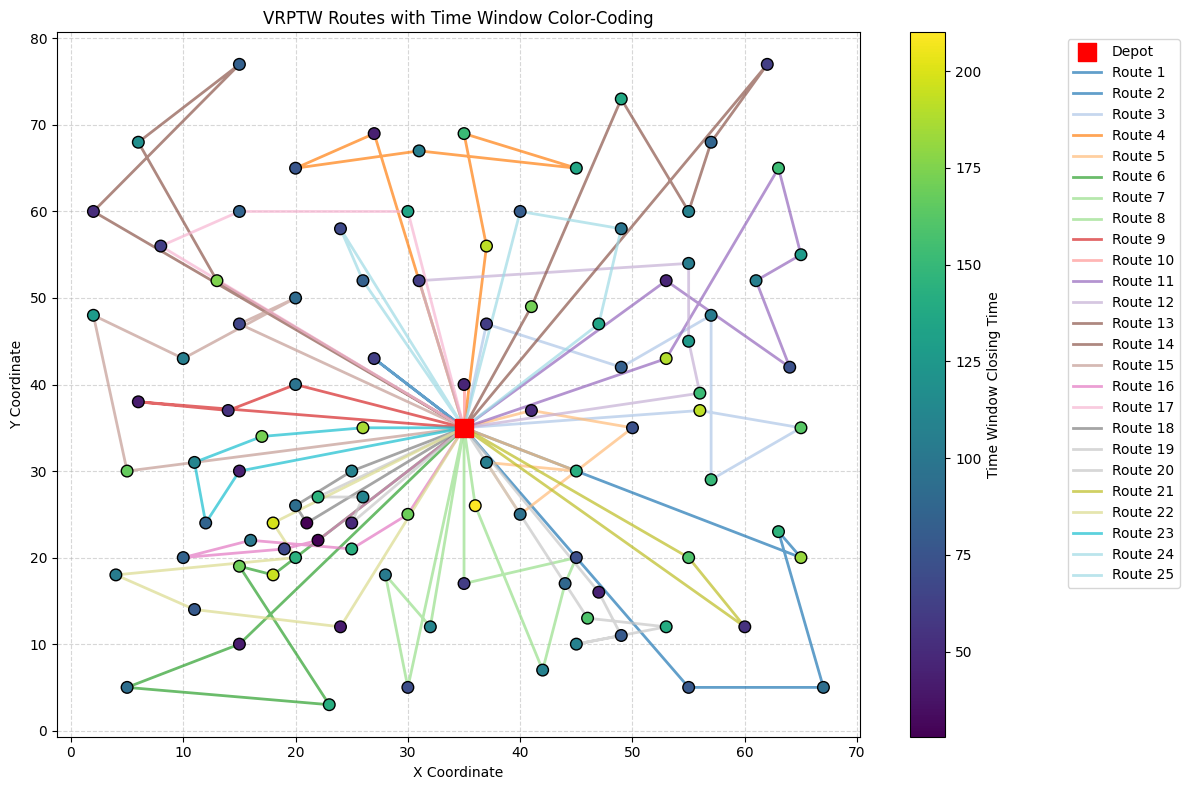

In [102]:
solver_vrptw = GRASP_VRPTW(vehicle_number, vehicle_capacity, depot, customers)
best_routes_vrptw, best_cost_vrptw = solver_vrptw.solve(iterations=100, alpha=0.3)
print(f"Best Cost for VRPTW: {best_cost_vrptw}")
print(f"Best Routes for VRPTW: {best_routes_vrptw}")
plot_vrptw_routes(depot, customers, best_routes_vrptw)

## AOC
Changes are the same as the changes done to the GRASP baseline including the time and vehicle constraint.
Heuristic is now now dynamic, instead of 1/distance we now calculate like in GRASP: 1 / (distance + wait time).
2-opt* as local search added at the end


In [ ]:
class ACO_VRPTW:
    def __init__(self, num_vehicles: int, vehicle_capacity: float, depot: Node, customers: List[Customer],
                 num_ants: int = 20, iterations: int = 100,
                 alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1, Q: float = 1.0):
        
        self.num_vehicles = num_vehicles
        self.capacity = vehicle_capacity
        self.depot = depot
        self.customers = customers
        
        # Node 0 is the depot. 
        # For VRPTW, depot has 0 demand, 0 open time, infinite close time, 0 service time
        self.nodes = [(depot[0], depot[1], 0.0, 0.0, float('inf'), 0.0)] + customers
        self.num_nodes = len(self.nodes)
        
        # ACO Parameters
        self.num_ants = num_ants
        self.iterations = iterations
        self.alpha = alpha   
        self.beta = beta     
        self.rho = rho       
        self.Q = Q           
        
        # Matrices
        self.distance_matrix = self._build_distance_matrix()
        
        self.tau_0 = 0.1 
        self.pheromone_matrix = [[self.tau_0] * self.num_nodes for _ in range(self.num_nodes)]

    # ---------------------------------------------------------
    # 1. UTILITY & EVALUATION METHODS
    # ---------------------------------------------------------
    def _build_distance_matrix(self) -> List[List[float]]:
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    matrix[i][j] = math.dist(self.nodes[i][:2], self.nodes[j][:2])
        return matrix

    def _evaluate_route(self, route: Route) -> Tuple[bool, float]:
        """Validates a single route strictly against time windows and capacity. Copied from GRASP."""
        if not route:
            return True, 0.0
            
        current_time = 0.0
        current_load = 0.0
        total_distance = 0.0
        current_node = 0 
        
        for next_node in route:
            demand = self.nodes[next_node][2]
            open_time = self.nodes[next_node][3]
            close_time = self.nodes[next_node][4]
            service_time = self.nodes[next_node][5]
            
            # Capacity Check
            current_load += demand
            if current_load > self.capacity:
                return False, float('inf')
                
            # Travel
            dist = self.distance_matrix[current_node][next_node]
            total_distance += dist
            current_time += dist
            
            # Time Window Check
            if current_time > close_time:
                return False, float('inf')
                
            # Wait and Service
            current_time = max(current_time, open_time) + service_time
            current_node = next_node
            
        # Return to Depot
        total_distance += self.distance_matrix[current_node][0]
        return True, total_distance

    def calculate_solution_cost(self, solution: Solution) -> float:
        """Sums the cost of all routes. Returns infinity if any route is invalid."""
        total_cost = 0.0
        for route in solution:
            is_valid, cost = self._evaluate_route(route)
            if not is_valid:
                return float('inf')
            total_cost += cost
        return total_cost

    # ---------------------------------------------------------
    # 2. ANT COLONY CONSTRUCTION METHODS
    # ---------------------------------------------------------
    def _select_next_node(self, current_node: int, unvisited: set, current_time: float, current_load: float) -> Tuple[int, float, float]:
        """Calculates dynamic transition probabilities using current time."""
        feasible_neighbors = []
        
        for j in unvisited:
            demand = self.nodes[j][2]
            open_time = self.nodes[j][3]
            close_time = self.nodes[j][4]
            service_time = self.nodes[j][5]
            
            if current_load + demand > self.capacity: continue
                
            arrival_time = current_time + self.distance_matrix[current_node][j]
            if arrival_time > close_time: continue
                
            start_service = max(arrival_time, open_time)
            departure_time = start_service + service_time
            wait_time = max(0, open_time - arrival_time)
            # urgency = close_time - current_time
            
            feasible_neighbors.append((j, departure_time, demand, wait_time))
            
        if not feasible_neighbors:
            return 0, current_time + self.distance_matrix[current_node][0], 0.0
            
        probabilities = []
        denominator = 0.0
        
        # 2. Calculate probabilities using the Dynamic Heuristic
        for j, dep_time, demand, wait in feasible_neighbors:
            tau = self.pheromone_matrix[current_node][j] ** self.alpha
            
            distance = self.distance_matrix[current_node][j]
            
            dynamic_eta = 1.0 / (distance + wait + 0.0001) 
            eta = dynamic_eta ** self.beta
            
            score = tau * eta
            probabilities.append((j, score, dep_time, demand))
            denominator += score
            
        rand_val = random.random()
        cumulative_prob = 0.0
        
        for j, score, dep_time, demand in probabilities:
            prob = score / denominator
            cumulative_prob += prob
            if rand_val <= cumulative_prob:
                return j, dep_time, demand
                
        fallback = probabilities[-1]
        return fallback[0], fallback[2], fallback[3]

    def _build_ant_solution(self) -> Tuple[Solution, bool]:
        """Simulates one ant building a full VRPTW solution, enforcing fleet limits."""
        unvisited = set(range(1, self.num_nodes))
        routes = []
        
        while unvisited:
            if len(routes) >= self.num_vehicles:
                return routes, False # Infeasible: Exceeded vehicle count
                
            current_route = []
            current_load = 0.0
            current_time = 0.0
            current_node = 0 
            
            while unvisited:
                next_node, new_time, added_demand = self._select_next_node(
                    current_node, unvisited, current_time, current_load
                )
                
                if next_node == 0:
                    break 
                    
                current_route.append(next_node)
                current_time = new_time
                current_load += added_demand
                unvisited.remove(next_node)
                current_node = next_node
                
            if current_route:
                routes.append(current_route)
                
        return routes, True

    # ---------------------------------------------------------
    # 3. PHEROMONE UPDATE & MAIN LOOP
    # ---------------------------------------------------------
    def _update_pheromones(self, best_solution: Solution, best_cost: float):
        """Applies evaporation and Elitist deposit based on the iteration's best valid solution."""
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                self.pheromone_matrix[i][j] *= (1.0 - self.rho)
                
        if best_cost == float('inf') or not best_solution:
            return # Don't deposit if no valid solution was found
            
        deposit_amount = self.Q / best_cost
        # print(f"Depositing pheromone for best solution with cost {best_cost:.2f}, deposit amount: {deposit_amount:.4f}")

        
        for route in best_solution:
            current_node = 0
            for node in route:
                self.pheromone_matrix[current_node][node] += deposit_amount
                self.pheromone_matrix[node][current_node] += deposit_amount 
                current_node = node
            self.pheromone_matrix[current_node][0] += deposit_amount
            self.pheromone_matrix[0][current_node] += deposit_amount

    def solve(self) -> Tuple[Solution, float]:
        """Standard ACO solver without Local Search (for testing)."""
        global_best_solution = None
        global_best_cost = float('inf')
        
        for iteration in range(self.iterations):
            iteration_best_solution = None
            iteration_best_cost = float('inf')
            
            for _ in range(self.num_ants):
                # Only evaluate solutions that respected the vehicle limit
                solution, is_feasible = self._build_ant_solution()
                
                if is_feasible:
                    cost = self.calculate_solution_cost(solution)
                    if cost < iteration_best_cost:
                        iteration_best_cost = cost
                        iteration_best_solution = solution

            if iteration_best_cost < global_best_cost:
                global_best_cost = iteration_best_cost
                global_best_solution = iteration_best_solution
                
            # Only update/evaporate if a valid solution was found
            if iteration_best_cost != float('inf'):
                self._update_pheromones(iteration_best_solution, iteration_best_cost)
            
            if iteration % 10 == 0:
                cost_str = f"{global_best_cost:.2f}" if global_best_cost != float('inf') else "No valid solution yet"
                print(f"Iteration {iteration}: Best Cost = {cost_str}")
                
        return global_best_solution, global_best_cost
    
    def _local_search_2opt_star(self, routes: List[Route]) -> List[Route]:
        """Applies 2-opt* inter-route optimization across all routes in a solution."""
        best_routes = [r.copy() for r in routes]
        improved = True
        
        while improved:
            improved = False
            
            # Iterate through all unique pairs of routes
            for r1_idx in range(len(best_routes)):
                for r2_idx in range(r1_idx + 1, len(best_routes)):
                    r1 = best_routes[r1_idx]
                    r2 = best_routes[r2_idx]
                    
                    if not r1 or not r2: continue
                    
                    # Calculate current combined cost of this pair
                    _, cost1 = self._evaluate_route(r1)
                    _, cost2 = self._evaluate_route(r2)
                    best_pair_cost = cost1 + cost2
                    
                    best_r1_new, best_r2_new = None, None
                    
                    # Try every combination of splitting r1 and r2
                    for i in range(len(r1)):
                        for j in range(len(r2)):
                            # The 2-opt* Swap: exchange the suffix of r1 with the suffix of r2
                            r1_new = r1[:i+1] + r2[j+1:]
                            r2_new = r2[:j+1] + r1[i+1:]
                            
                            # Evaluate the newly formed routes strictly
                            is_valid1, new_cost1 = self._evaluate_route(r1_new)
                            is_valid2, new_cost2 = self._evaluate_route(r2_new)
                            
                            if is_valid1 and is_valid2:
                                if new_cost1 + new_cost2 < best_pair_cost:
                                    # Found a cheaper, completely valid configuration!
                                    best_pair_cost = new_cost1 + new_cost2
                                    best_r1_new = r1_new
                                    best_r2_new = r2_new
                                    improved = True
                                    
                    # If an improvement was found, apply it and restart the search
                    if best_r1_new is not None:
                        best_routes[r1_idx] = best_r1_new
                        best_routes[r2_idx] = best_r2_new
                        break # Break inner loop
                if improved:
                    break # Break outer loop
                    
        # Filter out any routes that became empty during swapping
        return [r for r in best_routes if r]
    
    def solve_with_iteration_best_2opt_star(self) -> Tuple[Solution, float]:
        """Runs the Hybrid ACO, applying 2-opt* ONLY to the iteration's best ant."""
        global_best_solution = None
        global_best_cost = float('inf')
        
        for iteration in range(self.iterations):
            iteration_best_raw_solution = None
            iteration_best_raw_cost = float('inf')
            
            # 1. Construction Phase: All ants build raw solutions
            for ant in range(self.num_ants):
                raw_solution, is_feasible = self._build_ant_solution()
                
                if is_feasible:
                    # Evaluate the raw (unoptimized) cost just to find the best candidate
                    cost = self.calculate_solution_cost(raw_solution)
                    
                    if cost < iteration_best_raw_cost:
                        iteration_best_raw_cost = cost
                        iteration_best_raw_solution = raw_solution
                        
            # 2. Local Search Phase: ONLY optimize the best candidate
            iteration_best_solution = None
            iteration_best_cost = float('inf')
            
            if iteration_best_raw_solution is not None:
                # Apply 2-opt* strictly to the iteration's best raw route
                iteration_best_solution = self._local_search_2opt_star(iteration_best_raw_solution)
                
                # Calculate the true, finalized cost of the newly optimized solution
                iteration_best_cost = self.calculate_solution_cost(iteration_best_solution)
                
                # 3. Update Global Best
                if iteration_best_cost < global_best_cost:
                    global_best_cost = iteration_best_cost
                    global_best_solution = iteration_best_solution
                    
                # 4. Pheromone Update
                self._update_pheromones(iteration_best_solution, iteration_best_cost)
            
            # Print progress cleanly
            if iteration % 10 == 0:
                cost_str = f"{global_best_cost:.2f}" if global_best_cost != float('inf') else "Searching..."
                print(f"Iteration {iteration}: Best Cost = {cost_str}")
                
        return global_best_solution, global_best_cost

Iteration 0: Best Cost = 2036.65
Iteration 10: Best Cost = 1832.40
Iteration 20: Best Cost = 1805.95
Iteration 30: Best Cost = 1794.03
Iteration 40: Best Cost = 1782.01
Iteration 50: Best Cost = 1746.25
Iteration 60: Best Cost = 1746.25
Iteration 70: Best Cost = 1746.25
Iteration 80: Best Cost = 1746.25
Iteration 90: Best Cost = 1746.25
Iteration 100: Best Cost = 1742.41
Iteration 110: Best Cost = 1742.41
Iteration 120: Best Cost = 1742.41
Iteration 130: Best Cost = 1741.92
Iteration 140: Best Cost = 1741.92
Iteration 150: Best Cost = 1741.92
Iteration 160: Best Cost = 1741.92
Iteration 170: Best Cost = 1741.92
Iteration 180: Best Cost = 1741.92
Iteration 190: Best Cost = 1741.92
Best Cost from ACO: 1741.9158917063824
Best Solution (Routes): [[59, 5, 83, 16, 86, 37, 91, 100], [92, 42, 15, 87, 57, 97, 13, 89, 58], [63, 62, 11, 90, 20, 32, 70], [14, 44, 38, 43, 93], [36, 47, 19, 8, 46, 48], [33, 29, 78, 34, 35, 77], [28, 12, 76, 79, 3, 54, 24, 80], [95, 98, 61, 85, 96, 60], [39, 23, 67, 

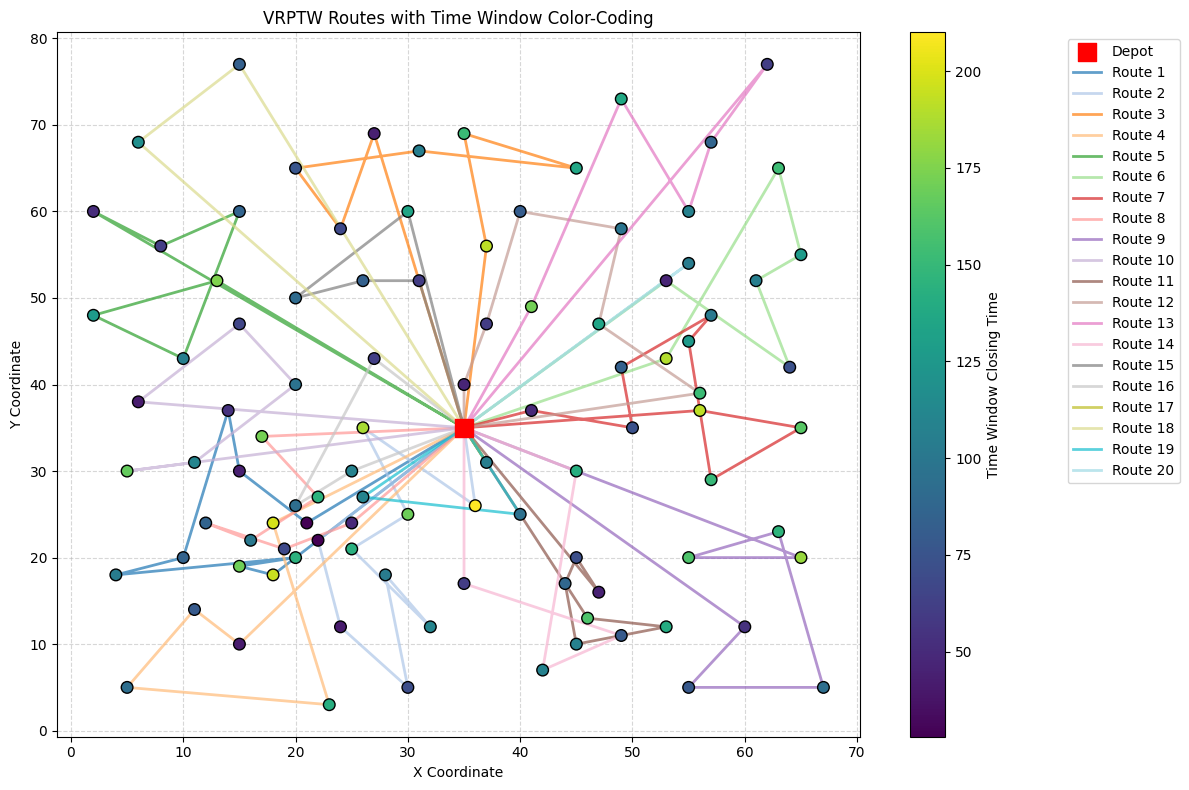

In [104]:
aco_solver_vrptw = ACO_VRPTW(vehicle_number, vehicle_capacity, depot, customers, num_ants=100, iterations=200, alpha=1.0, beta=5.0, rho=0.1, Q=1500.0)
best_solution_aco, best_cost_aco = aco_solver_vrptw.solve()
print(f"Best Cost from ACO: {best_cost_aco}")
print(f"Best Solution (Routes): {best_solution_aco}")
plot_vrptw_routes(depot, customers, best_solution_aco)

Iteration 0: Best Cost = 1688.01
Iteration 10: Best Cost = 1676.11
Iteration 20: Best Cost = 1676.11
Iteration 30: Best Cost = 1676.09
Iteration 40: Best Cost = 1676.09
Iteration 50: Best Cost = 1676.09
Iteration 60: Best Cost = 1676.09
Iteration 70: Best Cost = 1676.09
Iteration 80: Best Cost = 1676.09
Iteration 90: Best Cost = 1676.09
Iteration 100: Best Cost = 1676.09
Iteration 110: Best Cost = 1676.09
Iteration 120: Best Cost = 1676.09
Iteration 130: Best Cost = 1676.09
Iteration 140: Best Cost = 1676.09
Iteration 150: Best Cost = 1676.09
Iteration 160: Best Cost = 1674.91
Iteration 170: Best Cost = 1674.91
Iteration 180: Best Cost = 1674.91
Iteration 190: Best Cost = 1674.91
Best Cost from ACO with 2-opt*: 1674.90565233792
Best Solution (Routes): [[33, 29, 78, 34, 35, 77], [31, 88, 7], [72, 75, 22, 56, 74, 58], [92, 42, 15, 87, 57, 97, 13], [59, 5, 83, 61, 85, 37, 93], [14, 44, 38, 43, 91, 100], [27, 69, 30, 51, 20, 32, 70], [45, 82, 18, 84, 96], [28, 12, 76, 79, 3, 54, 24, 80], [

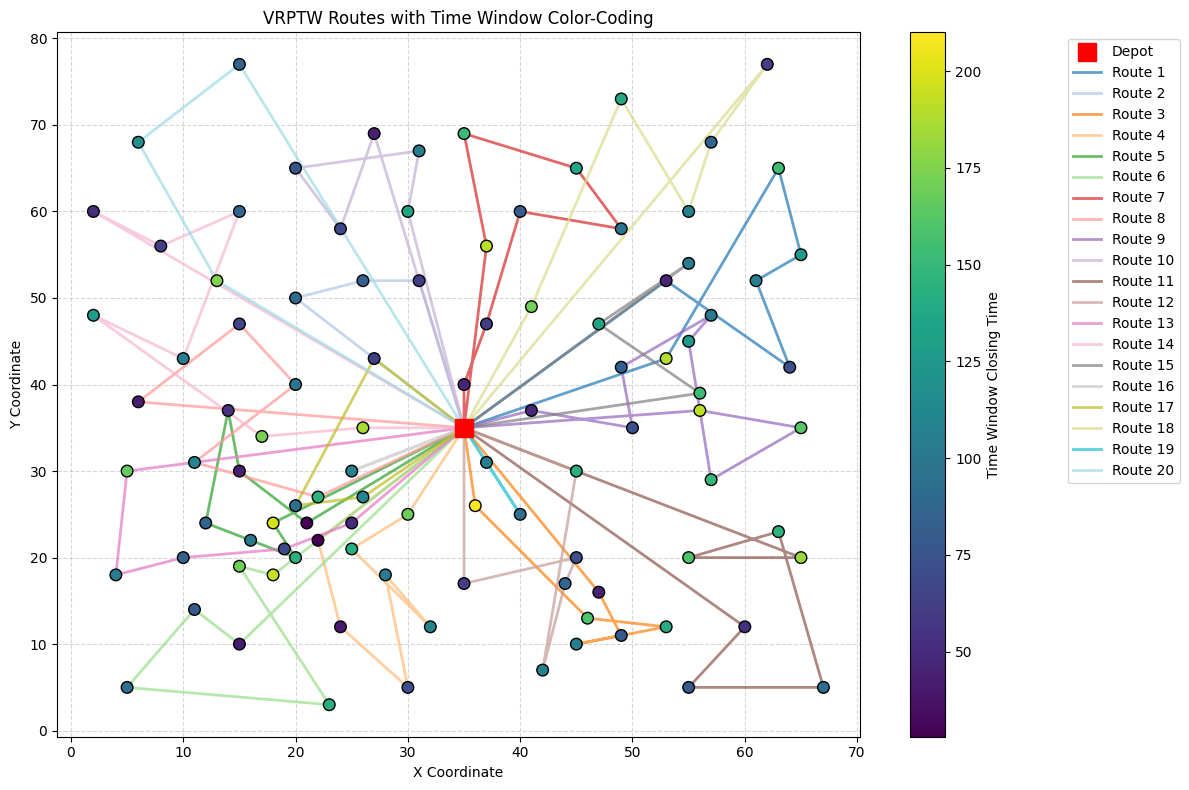

In [105]:
best_solution_aco, best_cost_aco = aco_solver_vrptw.solve_with_iteration_best_2opt_star()
print(f"Best Cost from ACO with 2-opt*: {best_cost_aco}")
print(f"Best Solution (Routes): {best_solution_aco}")
plot_vrptw_routes(depot, customers, best_solution_aco)

Noticeable improvement can be seen from the GRASP baseline -> AOC -> AOC with local search

## Parameter Tuning

In [106]:
def tune_vrptw_hyperparameters(num_vehicles, vehicle_capacity, depot, customers):
    # 1. Define the parameter grid
    alphas = [1.0, 2.0]            # Pheromone importance
    betas = [3.0, 5.0, 7.0]        # Heuristic importance (Higher is usually better for VRPTW)
    rhos = [0.1, 0.3]              # Evaporation rate
    
    # Generate all combinations
    param_combinations = list(itertools.product(alphas, betas, rhos))
    total_runs = len(param_combinations)
    print(f"Starting VRPTW Grid Search with {total_runs} combinations...\n")
    
    best_overall_cost = float('inf')
    best_params = None
    results = []
    
    # 2. Loop through every combination
    for idx, (alpha, beta, rho) in enumerate(param_combinations):
        for _ in range(3):
            print(f"[{idx+1}/{total_runs}] Testing: alpha={alpha}, beta={beta}, rho={rho}")
            
            start_time = time.time()
            
            # Instantiate the solver
            solver = ACO_VRPTW(
                num_vehicles=num_vehicles,
                vehicle_capacity=vehicle_capacity, 
                depot=depot, 
                customers=customers,
                num_ants=30,     
                iterations=80,    
                alpha=alpha, 
                beta=beta, 
                rho=rho,
                Q=1500.0           
            )
            
            # Run the highly-optimized Hybrid ACO
            best_solution, best_cost = solver.solve_with_iteration_best_2opt_star()
            
            elapsed_time = time.time() - start_time
            
            # Handle cases where the ants couldn't find a valid solution
            if best_cost == float('inf'):
                print(f"    -> Result: INFEASIBLE (Took {elapsed_time:.2f} seconds)\n")
            else:
                print(f"    -> Result: Cost = {best_cost:.2f} (Took {elapsed_time:.2f} seconds)\n")
            
            # Store results
            results.append({
                'alpha': alpha, 'beta': beta, 'rho': rho, 
                'cost': best_cost, 'time': elapsed_time
            })
            
            # Track the global best
            if best_cost < best_overall_cost:
                best_overall_solution = best_solution
                best_overall_cost = best_cost
                best_params = {'alpha': alpha, 'beta': beta, 'rho': rho}
            
    # 3. Output the final verdict
    print("-" * 40)
    print("VRPTW GRID SEARCH COMPLETE")
    print("-" * 40)
    if best_params:
        print(f"Best Parameters: {best_params}")
        print(f"Best Cost Found: {best_overall_cost:.2f}")
    else:
        print("CRITICAL WARNING: No parameter combination found a feasible solution.")
        print("Try increasing the test 'num_ants' or 'iterations'.")
        
    return best_params, results, best_overall_solution

Starting VRPTW Grid Search with 12 combinations...

[1/12] Testing: alpha=1.0, beta=3.0, rho=0.1
Iteration 0: Best Cost = 1942.40
Iteration 10: Best Cost = 1695.31
Iteration 20: Best Cost = 1695.31
Iteration 30: Best Cost = 1688.00
Iteration 40: Best Cost = 1688.00
Iteration 50: Best Cost = 1688.00
Iteration 60: Best Cost = 1688.00
Iteration 70: Best Cost = 1682.96
    -> Result: Cost = 1682.96 (Took 7.63 seconds)

[1/12] Testing: alpha=1.0, beta=3.0, rho=0.1
Iteration 0: Best Cost = 1911.88
Iteration 10: Best Cost = 1706.32
Iteration 20: Best Cost = 1701.42
Iteration 30: Best Cost = 1697.91
Iteration 40: Best Cost = 1697.91
Iteration 50: Best Cost = 1697.91
Iteration 60: Best Cost = 1696.56
Iteration 70: Best Cost = 1696.56
    -> Result: Cost = 1696.56 (Took 7.67 seconds)

[1/12] Testing: alpha=1.0, beta=3.0, rho=0.1
Iteration 0: Best Cost = 1810.13
Iteration 10: Best Cost = 1704.21
Iteration 20: Best Cost = 1676.50
Iteration 30: Best Cost = 1676.50
Iteration 40: Best Cost = 1676.50


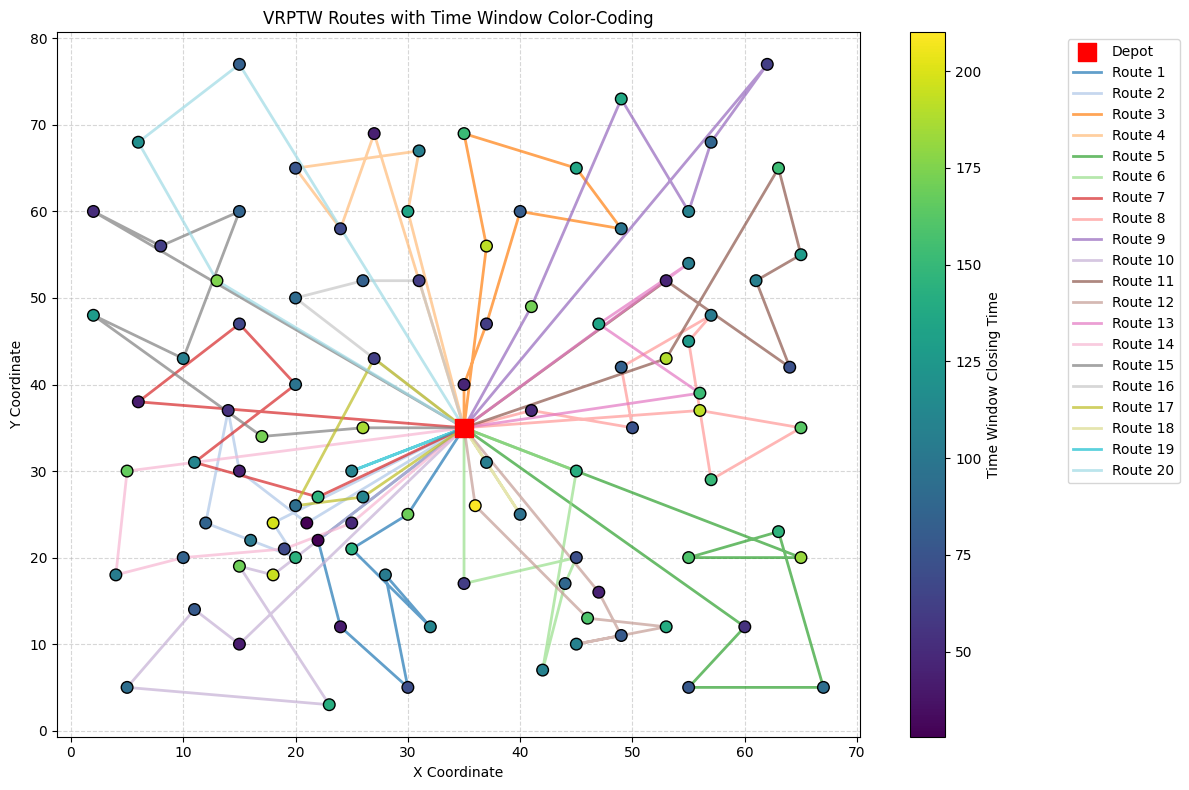

In [107]:
best_vrptw_params, all_vrptw_results, best_vrptw_solution = tune_vrptw_hyperparameters(vehicle_number, vehicle_capacity, depot, customers)
plot_vrptw_routes(depot, customers, best_vrptw_solution)